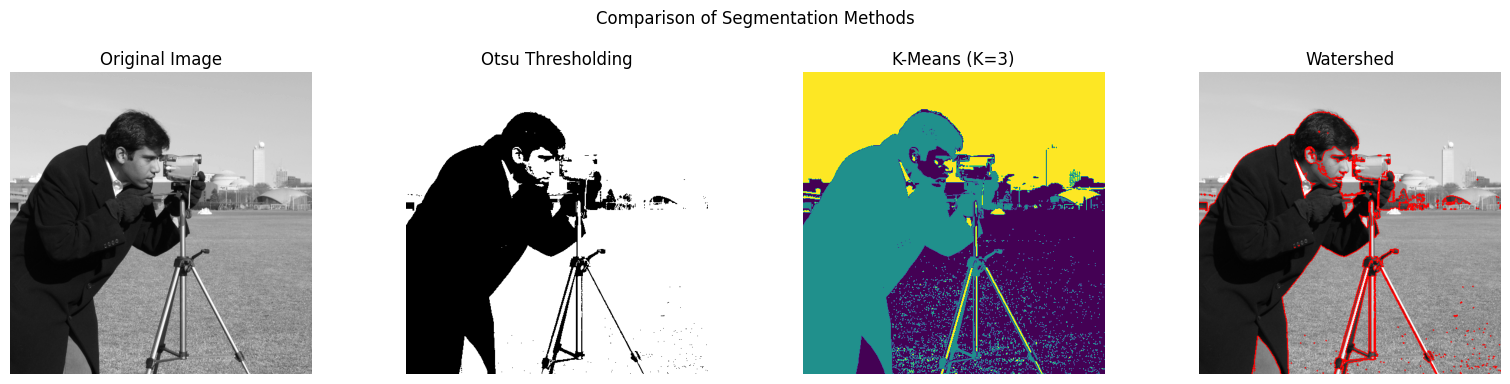

In [1]:
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float, color
from sklearn.cluster import KMeans
import numpy as np
import warnings

# 1. Pilih satu citra untuk perbandingan (misal: camera)
image = data.camera()
image_float = img_as_float(image)

# 2. Lakukan beberapa metode segmentasi
# a) Otsu Thresholding
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# b) K-Means (misal K=3)
# Reshape untuk K-Means (1 fitur: intensitas)
rows, cols = image.shape
pixel_features = image_float.reshape(rows * cols, 1)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)
segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

# c) Watershed (gunakan marker sederhana dari Otsu)
elevation_map = filters.sobel(image)
markers = np.zeros_like(image)
markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# 3. Visualisasi Perbandingan
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans_labels, cmap='viridis') # Gunakan cmap berbeda untuk label
ax[2].set_title(f'K-Means (K={n_clusters})')
ax[2].axis('off')

# Gunakan mark_boundaries untuk Watershed agar lebih jelas
segmented_watershed_colored = segmentation.mark_boundaries(image_float, segmentation_watershed, color=(1,0,0)) # Batas merah
ax[3].imshow(segmented_watershed_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.suptitle('Comparison of Segmentation Methods')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

Bandingkan hasil ketiga metode pada citra yang sama. Metode mana yang paling baik dalam memisahkan objek utama? Metode mana yang menghasilkan region paling halus atau paling detail? Apa kelebihan dan kekurangan masing-masing metode berdasarkan hasil visual ini?

ANALISIS MENDALAM PERBANDINGAN SEGMENTASI

1. JUMLAH REGION:
   - Otsu: 1 region (biner: object/background)
   - K-Means: 3 region (K=3)
   - Watershed: 2 region


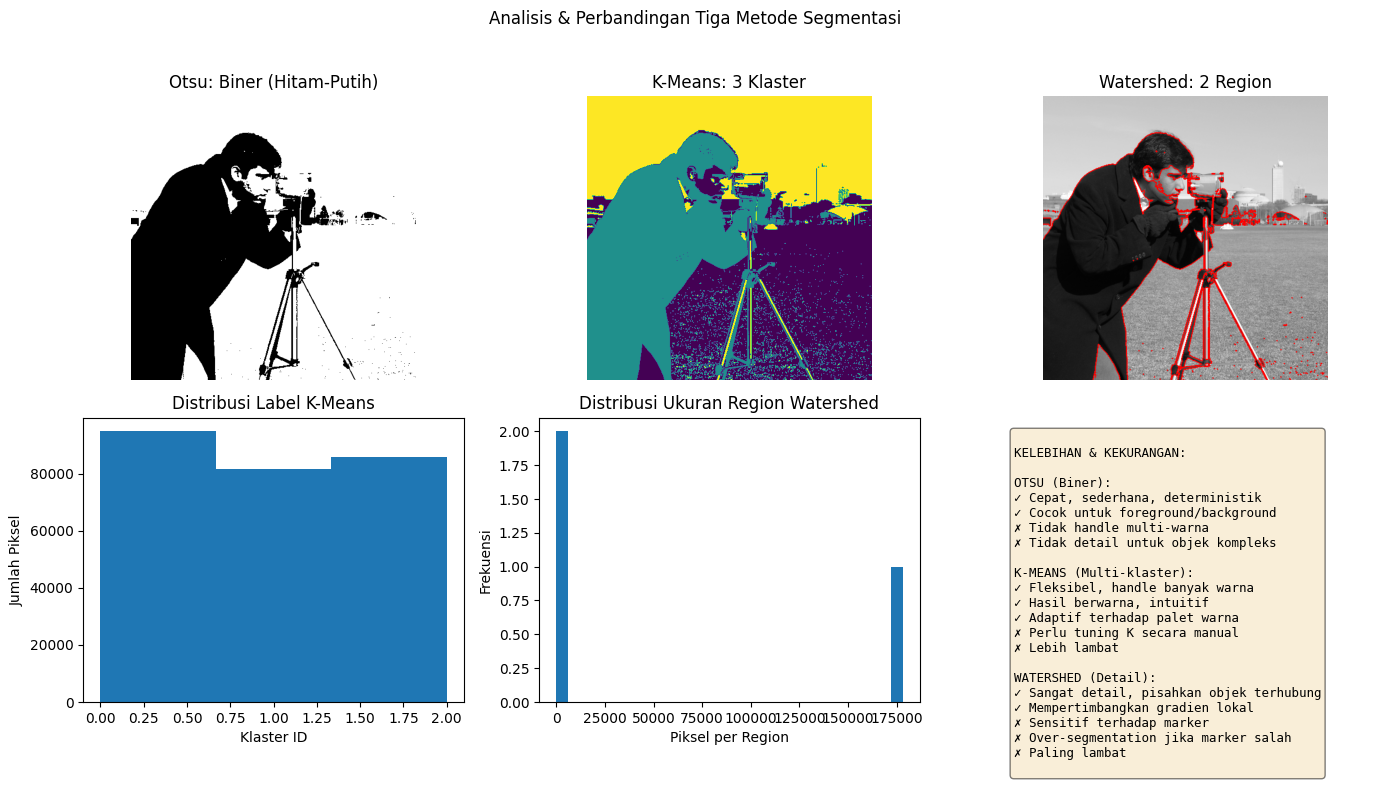


2. KARAKTERISTIK HASIL:
   Otsu:
   - Output: Biner (hitam-putih saja)
   - Kecepatan: Sangat cepat
   - Detail: Rendah (hanya 2 level)

   K-Means:
   - Output: Multi-warna (K=3 warna berbeda)
   - Kecepatan: Sedang
   - Detail: Sedang (tergantung K)

   Watershed:
   - Output: Banyak region dengan boundary jelas
   - Kecepatan: Lambat
   - Detail: Sangat tinggi, pisahkan objek terhubung

3. KAPAN GUNAKAN METODE MANA?
   • Otsu: Deteksi cepat, foreground-background sederhana
   • K-Means: Analisis multi-warna, quantization, texture
   • Watershed: Pemisahan objek detail, medical imaging

✓ KESIMPULAN UMUM:
Tidak ada metode 'terbaik' universal - pilih berdasarkan:
  1. Tipe citra (mono/color, kompleksitas)
  2. Tujuan (deteksi cepat vs detail tinggi)
  3. Trade-off kecepatan vs akurasi


In [2]:
# Tugas Lanjutan: Analisis mendalam perbandingan ketiga metode
print("=" * 60)
print("ANALISIS MENDALAM PERBANDINGAN SEGMENTASI")
print("=" * 60)

# Hitung statistik untuk setiap metode
num_regions_otsu = len(np.unique(binary_otsu)) - 1  # Exclude background
num_regions_kmeans = n_clusters
num_regions_ws = np.max(segmentation_watershed)

print(f"\n1. JUMLAH REGION:")
print(f"   - Otsu: {num_regions_otsu} region (biner: object/background)")
print(f"   - K-Means: {num_regions_kmeans} region (K={n_clusters})")
print(f"   - Watershed: {num_regions_ws} region")

# Visualisasi perbandingan dengan analisis
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Row 1: Hasil segmentasi
axes[0, 0].imshow(binary_otsu, cmap='gray')
axes[0, 0].set_title('Otsu: Biner (Hitam-Putih)')
axes[0, 0].axis('off')

axes[0, 1].imshow(segmented_kmeans_labels, cmap='viridis')
axes[0, 1].set_title(f'K-Means: {n_clusters} Klaster')
axes[0, 1].axis('off')

axes[0, 2].imshow(segmented_watershed_colored)
axes[0, 2].set_title(f'Watershed: {num_regions_ws} Region')
axes[0, 2].axis('off')

# Row 2: Histogram
# Hitung distribusi ukuran region
from scipy import ndimage as nd
sizes_ws = nd.sum(binary_otsu, segmentation_watershed, range(num_regions_ws + 1))

axes[1, 0].hist(segmented_kmeans_labels.ravel(), bins=n_clusters)
axes[1, 0].set_title('Distribusi Label K-Means')
axes[1, 0].set_xlabel('Klaster ID')
axes[1, 0].set_ylabel('Jumlah Piksel')

axes[1, 1].hist(sizes_ws, bins=30)
axes[1, 1].set_title('Distribusi Ukuran Region Watershed')
axes[1, 1].set_xlabel('Piksel per Region')
axes[1, 1].set_ylabel('Frekuensi')

axes[1, 2].axis('off')
analysis_text = f"""
KELEBIHAN & KEKURANGAN:

OTSU (Biner):
✓ Cepat, sederhana, deterministik
✓ Cocok untuk foreground/background
✗ Tidak handle multi-warna
✗ Tidak detail untuk objek kompleks

K-MEANS (Multi-klaster):
✓ Fleksibel, handle banyak warna
✓ Hasil berwarna, intuitif
✓ Adaptif terhadap palet warna
✗ Perlu tuning K secara manual
✗ Lebih lambat

WATERSHED (Detail):
✓ Sangat detail, pisahkan objek terhubung
✓ Mempertimbangkan gradien lokal
✗ Sensitif terhadap marker
✗ Over-segmentation jika marker salah
✗ Paling lambat
"""
axes[1, 2].text(0.05, 0.95, analysis_text, transform=axes[1, 2].transAxes,
               fontsize=9, verticalalignment='top', family='monospace',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Analisis & Perbandingan Tiga Metode Segmentasi', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print(f"\n2. KARAKTERISTIK HASIL:")
print(f"   Otsu:")
print(f"   - Output: Biner (hitam-putih saja)")
print(f"   - Kecepatan: Sangat cepat")
print(f"   - Detail: Rendah (hanya 2 level)")
print(f"\n   K-Means:")
print(f"   - Output: Multi-warna (K=3 warna berbeda)")
print(f"   - Kecepatan: Sedang")
print(f"   - Detail: Sedang (tergantung K)")
print(f"\n   Watershed:")
print(f"   - Output: Banyak region dengan boundary jelas")
print(f"   - Kecepatan: Lambat")
print(f"   - Detail: Sangat tinggi, pisahkan objek terhubung")

print(f"\n3. KAPAN GUNAKAN METODE MANA?")
print(f"   • Otsu: Deteksi cepat, foreground-background sederhana")
print(f"   • K-Means: Analisis multi-warna, quantization, texture")
print(f"   • Watershed: Pemisahan objek detail, medical imaging")

print(f"\n✓ KESIMPULAN UMUM:")
print(f"Tidak ada metode 'terbaik' universal - pilih berdasarkan:")
print(f"  1. Tipe citra (mono/color, kompleksitas)")
print(f"  2. Tujuan (deteksi cepat vs detail tinggi)")
print(f"  3. Trade-off kecepatan vs akurasi")